## <div style="text-align: center; background-color:#ffffff;  color: black; border:black; border-width:1.5px; border-style:solid; font-family: Times New Roman; padding: 14px; line-height: 0.5;"> <b>🏡   Home Loan Approval Prediction   🏡</b></div>

# Business understanding

<p style="font-size: 18px;"><b>HomeLoan Overview</b></p>
<p>A home loan, also known as a housing loan or a mortgage, is a type of loan provided by financial institutions, such as banks or housing finance companies, to help individuals or families purchase a house. Home loans are typically long-term loans, ranging from 5 to 30 years, and are secured by the property being purchased.</p>

<p>The loan amount and the interest rate offered by the lender will depend on various factors such as the borrower's income, credit score, employment history, the value of the property, and the down payment made by the borrower. Generally, borrowers are required to make a down payment of 10-20% of the property value and the lender provides the remaining amount as a loan.</p>

<p>When a borrower takes out a home loan, they are required to repay the loan amount along with interest over the loan tenure through monthly installments. Defaulting on home loan payments can lead to penalties and even foreclosure of the property by the lender.</p>

<p>Overall, home loans can help individuals and families achieve their dream of owning a home, but it is important to carefully consider the terms and conditions of the loan and ensure that the monthly repayments are affordable before committing to a loan.</p>



<p style="font-size: 18px;"><b>About Company</b></p>
<p>Dream Housing Finance company deals in all home loans. They have a presence across all urban, semi-urban and rural areas. The customer first applies for a home loan after that company validates the customer's eligibility for a loan.</p>


<p style="font-size: 18px;"><b>Problem Statement</b></p>
<p>The company wants to automate the loan eligibility process (real-time) based on customer detail provided while filling out the online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have given a problem identifying the customer segments eligible for loan amounts to target these customers specifically. </p>

In [144]:
#Target = 'Loan_Status'

#Problem Type = Classification

#Goal = To Build Best model to automate loan eligiblity process

#Who is the stakeholder? : Housing Finance Company

#Which is more risky: approving defaulter OR rejecting good customer? : approving defaulter

#Which metric matters most? Recall? Precision? : Precision of TP,least FP


## Importing Libraries

In [1]:
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#ignoring warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

## Reading Datasets from csv files

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rishikeshkonapure/home-loan-approval")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'home-loan-approval' dataset.
Path to dataset files: /kaggle/input/home-loan-approval


In [143]:
# shell command
#!ls /root/.cache/kagglehub/datasets/rishikeshkonapure/home-loan-approval/versions/1


In [20]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/rishikeshkonapure/home-loan-approval/versions/1/loan_sanction_train.csv')

In [21]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# Exploratory Data Analysis

Why EDA?

Prevents bad outputs: It stops "garbage in, garbage out" by catching data errors early.

What are we trying to find?

Missing values: Gaps or null spots that need fixing or removal.

Outliers: Extreme values or errors that skew training.

Data distribution: How values spread out (like skewness or bell curves).

Variable relationships: Which features connect to each other or predict the target outcome.

Class imbalances: Unequal target categories that break model predictions.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.describe() # summarizes only numeric columns

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.describe(include="object") # summarizes only object columns

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [8]:
desc = df.describe(include="object")
desc.loc['freq_%'] = (desc.loc['freq'] / desc.loc['count']) * 100
desc

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422
freq_%,0.162866,81.364393,65.139116,57.595993,78.175896,85.910653,37.947883,68.729642


In [9]:
# Print unique values for each column
for col in df[['Gender', 'Married', 'Dependents', 'Education','Self_Employed','Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']].columns:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'Gender': ['Male' 'Female' nan]
Unique values in 'Married': ['No' 'Yes' nan]
Unique values in 'Dependents': ['0' '1' '2' '3+' nan]
Unique values in 'Education': ['Graduate' 'Not Graduate']
Unique values in 'Self_Employed': ['No' 'Yes' nan]
Unique values in 'Loan_Amount_Term': [360. 120. 240.  nan 180.  60. 300. 480.  36.  84.  12.]
Unique values in 'Credit_History': [ 1.  0. nan]
Unique values in 'Property_Area': ['Urban' 'Rural' 'Semiurban']
Unique values in 'Loan_Status': ['Y' 'N']


In [10]:
# Check for nan values
df.isnull().sum()
#df.isnull().sum()[df.isnull().sum()>0].index

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# missing values: 'Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount','Loan_Amount_Term', 'Credit_History'

In [11]:
df[df.isna().any(axis=1)]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
16,LP001034,Male,No,1,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,LP002933,NaN,No,3+,Graduate,Yes,9357,0.0,292.0,360.0,1.0,Semiurban,Y
597,LP002943,Male,No,NaN,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N
600,LP002949,Female,No,3+,Graduate,NaN,416,41667.0,350.0,180.0,NaN,Urban,N
601,LP002950,Male,Yes,0,Not Graduate,NaN,2894,2792.0,155.0,360.0,1.0,Rural,Y


In [13]:
df.duplicated().sum()

np.int64(0)

## Plots

In [16]:
# Optional
#[TODO] Gender vs loan status
#[TODO] Property types vs loan status
#[TODO] Applicant income vs loan status

# Data Preparation

### Data Cleansing Notes

Note: Missing values rows are dropped here for lab convenience/time constraints.

### The Risks of Prematurely Dropping Missing Values

Dropping rows with missing values—especially in large quantities—can severely compromise your analysis and model performance for three main reasons:

1. **Loss of Information:** Eliminating records removes valuable data that may contain critical patterns in its complete features. This drastically shrinks your dataset, making subsequent machine learning models far less robust.
2. **Systemic Bias:** If data is not Missing Completely at Random (MCAR)—meaning the missingness is tied to other variables or the value itself—dropping rows introduces heavy bias. Your model may end up learning relationships that do not exist in the true population.
3. **Reduced Statistical Power:** Smaller datasets inherently have less statistical power. This makes it significantly harder to detect true mathematical effects or relationships within the data.

### Robust Alternatives to Dropping Data

In a production workflow, a superior approach is **imputation**—the process of filling in missing gaps with statistically sound substitute values. The optimal strategy depends entirely on your data type and the underlying cause of the missing data.

#### Common Imputation Strategies:
* **Numerical Columns (Median Imputation):** Replacing missing entries with the median is highly recommended for skewed distributions or datasets containing severe outliers, as the median remains unaffected by extreme values.
* **Categorical Columns (Mode Imputation):** Replacing missing values with the mode (the most frequent value) ensures the category remains consistent with the most common class.
* **Advanced Algorithmic Imputation:** For maximum accuracy, you can use advanced techniques like **KNN (K-Nearest Neighbors)** which predict missing values based on relationships with all other features in the dataset.

By imputing instead of deleting, you preserve the dataset's size and integrity, ultimately leading to more accurate, reliable, and generalizable models.


## Drop missing values

In [23]:
print('All the Null values are dropped from the Dataset')
df.dropna(inplace=True)
df.isnull().sum()

All the Null values are dropped from the Dataset


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [24]:
# Drop column loan id
df = df.drop('Loan_ID',axis = 1)
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [25]:
# Sum ApplicationIncome and CoApplicantIncome together
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
# df = df.drop(['ApplicantIncome','CoapplicantIncome'], axis=1)
# df

## Fix Dtypes

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             480 non-null    object 
 1   Married            480 non-null    object 
 2   Dependents         480 non-null    object 
 3   Education          480 non-null    object 
 4   Self_Employed      480 non-null    object 
 5   ApplicantIncome    480 non-null    int64  
 6   CoapplicantIncome  480 non-null    float64
 7   LoanAmount         480 non-null    float64
 8   Loan_Amount_Term   480 non-null    float64
 9   Credit_History     480 non-null    float64
 10  Property_Area      480 non-null    object 
 11  Loan_Status        480 non-null    object 
 12  TotalIncome        480 non-null    float64
dtypes: float64(5), int64(1), object(7)
memory usage: 52.5+ KB


In [27]:
df['Dependents'].unique()

array(['1', '0', '2', '3+'], dtype=object)

In [28]:
# correct dtypes
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

In [29]:
df['Dependents'].unique()

array([1, 0, 2, 3])

In [30]:
# Correct data_types
#for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status','Credit_History']:
#    df[col] = df[col].astype('category')

df['Gender']=df['Gender'].astype('category')
df['Married']=df['Married'].astype('category')
df['Education']=df['Education'].astype('category')
df['Self_Employed'] = df['Self_Employed'].astype('category')
df['Property_Area']=df['Property_Area'].astype('category')
df['Loan_Status']=df['Loan_Status'].astype('category')
df['Credit_History']=df['Credit_History'].astype('category')


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Gender             480 non-null    category
 1   Married            480 non-null    category
 2   Dependents         480 non-null    int64   
 3   Education          480 non-null    category
 4   Self_Employed      480 non-null    category
 5   ApplicantIncome    480 non-null    int64   
 6   CoapplicantIncome  480 non-null    float64 
 7   LoanAmount         480 non-null    float64 
 8   Loan_Amount_Term   480 non-null    float64 
 9   Credit_History     480 non-null    category
 10  Property_Area      480 non-null    category
 11  Loan_Status        480 non-null    category
 12  TotalIncome        480 non-null    float64 
dtypes: category(7), float64(4), int64(2)
memory usage: 30.4 KB


# Features Engineering

## Encoding

In [32]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [33]:
# Encoding Decision:
# LabelEncoder : Gender,Married,Self_Employed,Credit_History,Loan_Status,Education (encoded using alphabetical order)
#                reason : has only two categories
# ordinal encoding : Property_Area
#                  reason: give a ranking order


In [34]:
df_encode = df.copy()

In [35]:
label = LabelEncoder()
#for col in ['Gender', 'Married', 'Self_Employed', 'Credit_History', 'Loan_Status', 'Education']:
#    df_encode[col] = label.fit_transform(df_encode[col])

df_encode['Gender'] = label.fit_transform(df_encode['Gender'])
df_encode['Married'] = label.fit_transform(df_encode['Married'])
df_encode['Self_Employed']=label.fit_transform(df_encode['Self_Employed'])
df_encode['Credit_History']=label.fit_transform(df_encode['Credit_History'])
df_encode['Loan_Status']=label.fit_transform(df_encode['Loan_Status'])
df_encode['Education'] = label.fit_transform(df_encode['Education'])

property_encoder = OrdinalEncoder(categories=[['Rural', 'Semiurban', 'Urban']])
df_encode['Property_Area'] = property_encoder.fit_transform(df_encode[['Property_Area']]).astype(int)


In [36]:
df_encode

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,0,6091.0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1,2,1,3000.0
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1,2,1,4941.0
4,1,0,0,0,0,6000,0.0,141.0,360.0,1,2,1,6000.0
5,1,1,2,0,1,5417,4196.0,267.0,360.0,1,2,1,9613.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,2900,0.0,71.0,360.0,1,0,1,2900.0
610,1,1,3,0,0,4106,0.0,40.0,180.0,1,0,1,4106.0
611,1,1,1,0,0,8072,240.0,253.0,360.0,1,2,1,8312.0
612,1,1,2,0,0,7583,0.0,187.0,360.0,1,2,1,7583.0


## Correlation

<Axes: title={'center': 'Correlation'}>

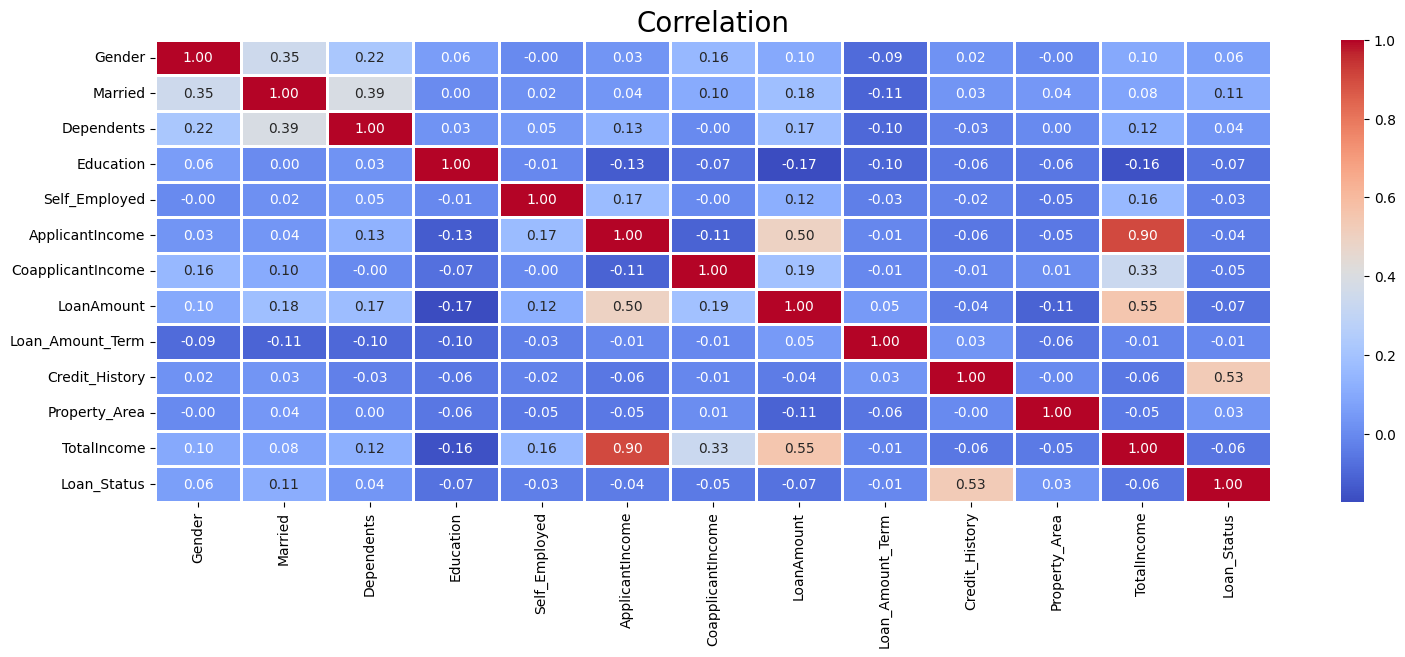

In [39]:
plt.figure(figsize=(18, 6))
plt.title('Correlation', fontsize =20)
sns.heatmap(df_encode[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome',
       'Loan_Status']].corr(),
            cmap='coolwarm',
            fmt = '.2f',
            linewidths = 2,
            annot = True)

In [40]:
df_cleaned = df_encode.copy()

In [41]:
df_cleaned.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'TotalIncome'],
      dtype='object')

## Train test split

In [42]:
X = df_cleaned[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount','TotalIncome','Loan_Amount_Term', 'Credit_History', 'Property_Area']]

y = df_cleaned['Loan_Status']

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

#Modeling

## Logistic Regression Model

In [97]:
from sklearn.linear_model import LogisticRegression


In [86]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [87]:
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1])

# Evaluation

In [98]:
from sklearn.metrics import classification_report,accuracy_score,f1_score,confusion_matrix,precision_score,ConfusionMatrixDisplay

In [88]:
pd.DataFrame({'y_pred': y_pred, 'y_test': y_test})[:20]

,y_pred,y_test
352,1,1
598,1,1
455,1,1
540,1,1
82,1,0
522,1,1
398,1,1
242,1,1
541,0,0
582,1,1


In [99]:
accuracy_score(y_test,y_pred)

0.8333333333333334

In [100]:
confusion_matrix(y_test,y_pred)

array([[17, 14],
       [ 2, 63]])

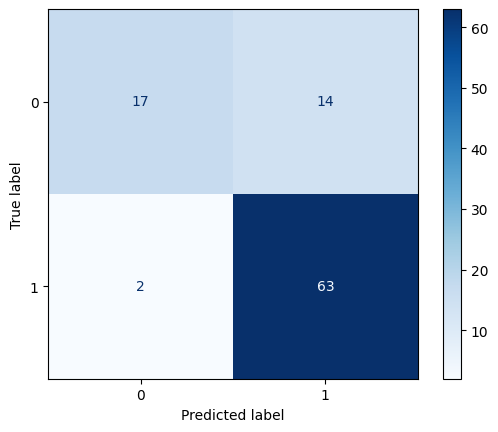

In [102]:
cm = confusion_matrix(y_test, y_pred)

# Display and plot the matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["0", "1"]
)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [104]:
tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel()
print('tn:',tn,',fp:', fp,',fn', fn,',tp', tp)

tn: 17 ,fp: 14 ,fn 2 ,tp 63


In [ ]:
precision = precision_score(y_true, y_pred)


# How to improve model?

In [142]:
# Check whether the nan values contain meaningful info
# Perform check for data distribution
# Check Data Imbalance
# apply upscale if needed
# Perform normalisation
# Should we use all columns
# Use Random Forest and other algorithms

In [1]:
import pickle
# 1. Save/Export the model
with open("logistic_model.pkl", "wb") as file:
    pickle.dump(model, file)

# 2. How to load it back later:
# with open("logistic_model.pkl", "rb") as file:
#     loaded_model = pickle.load(file)